This file achieves similar objectives as the other file. However, this file calls SAM3 through a helper function. This is done to help organize the workflow when integrated with OpenPIV. 

In [1]:
import os
from Scripts.FlowSeg import FlowSeg
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


This step reads the input image and starts the SAM3 function, the output is the mask in boolean numpy array

In [2]:
Name1="Frame_00001.tif" #Change name for PIV image used to generate mask
InputPath=os.path.join(os.getcwd(),"input")
GenPath=os.path.join(os.getcwd(),"input",Name1)

MaskOut=FlowSeg(GenPath,"Black Shape")


/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased
Check the latest .pth from: https://github.com/IDEA-Research/GroundingDINO/releases


/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/transformers/modeling_utils.py:1052: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/site-packages/torch/utils/checkpoint.py:238: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/home/leo/miniforge3/envs/FlowSegClean/lib/python3.12/

Height: 2052
Width: 4603
X: 2301
Y: 1716
Mask shape: (1, 2652, 5203)
(2652, 5203)
(2652, 5203)
(2052, 4603)


Visualize the Mask

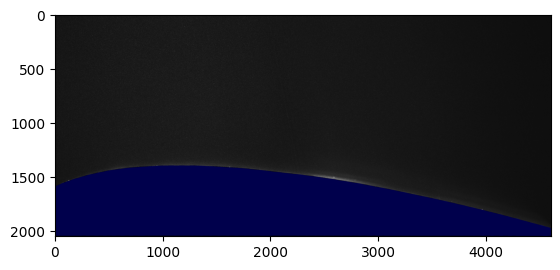

In [3]:
Source = cv2.imread(GenPath)

CroppedMask=MaskOut.astype(np.uint8) * 255
color_mask = cv2.cvtColor(CroppedMask, cv2.COLOR_GRAY2BGR)
color_mask[MaskOut] = [255, 0, 0] # Blue BGR

img = cv2.addWeighted(color_mask, 0.3, Source, 1, 0)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [4]:
torch.cuda.empty_cache()